# 🚕 NYC Taxi Duration Prediction — MLflow Experiment Tracking

**Models covered:** Linear Regression · Lasso · Ridge · XGBoost  
**Tracking:** MLflow Remote Tracking Server (AWS EC2 + RDS PostgreSQL + S3)  
**Tracking URI:** `http://ec2-16-16-201-85.eu-north-1.compute.amazonaws.com:5000`  
**Data:** NYC Green Taxi Trip Records (Jan–Feb 2021)


## Cell 1: Install & Setup

In [ ]:
# Install MLflow, XGBoost, and boto3 (required for S3 artifact storage)
!pip install mlflow xgboost boto3 --quiet
!python -V


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.7 MB/s eta 0:00:00
Python 3.12.13


## Cell 2: Imports

In [ ]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import root_mean_squared_error
import xgboost as xgb
from xgboost import XGBRegressor

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

print(f"MLflow version: {mlflow.__version__}")

MLflow version: 3.10.1


## Cell 3: Download Data (if needed)

In [ ]:
import urllib.request

os.makedirs('./data', exist_ok=True)

BASE_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data"

# Green taxi data is available from 2019 onwards in parquet format
# Data is published with ~2 month delay, so up to Jan 2026 as of now
years_months = [
    (year, month)
    for year in range(2019, 2027)
    for month in range(1, 13)
]
years_months = [(y, m) for y, m in years_months if (y, m) <= (2026, 1)]

failed = []

for year, month in years_months:
    filename = f"green_tripdata_{year}-{month:02d}.parquet"
    filepath = f"./data/{filename}"

    if os.path.exists(filepath):
        print(f"✓ Already exists: {filename}")
        continue

    url = f"{BASE_URL}/{filename}"
    try:
        print(f"Downloading {filename}...", end=" ")
        urllib.request.urlretrieve(url, filepath)
        print("✓ Done")
    except Exception as e:
        print(f"✗ Failed: {e}")
        failed.append(filename)
        if os.path.exists(filepath):
            os.remove(filepath)

print("\n--- Summary ---")
print(f"Downloaded successfully to ./data/")
if failed:
    print(f"Failed ({len(failed)}):")
    for f in failed:
        print(f"  - {f}")
else:
    print("All files downloaded!")


--- Summary ---
Downloaded successfully to ./data/
Failed (2):
  - green_tripdata_2025-12.parquet
  - green_tripdata_2026-01.parquet


## Cell 4: MLflow Setup

In [ ]:
REMOTE_TRACKING_URI = "http://ec2-16-16-201-85.eu-north-1.compute.amazonaws.com:5000"

# Point to the shared remote tracking server (EC2 + RDS PostgreSQL + S3)
mlflow.set_tracking_uri(REMOTE_TRACKING_URI)

# Name our experiment — groups all related runs together
EXPERIMENT_NAME = "nyc-taxi-duration-prediction"
mlflow.set_experiment(EXPERIMENT_NAME)

# Create folders
os.makedirs('./data', exist_ok=True)
os.makedirs('./models', exist_ok=True)

print(f"Experiment     : {EXPERIMENT_NAME}")
print(f"Tracking URI   : {mlflow.get_tracking_uri()}")
print(f"MLflow UI      : http://ec2-16-16-201-85.eu-north-1.compute.amazonaws.com:5000")


2026/03/25 06:33:30 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/25 06:33:30 INFO mlflow.store.db.utils: Updating database tables
2026/03/25 06:33:33 INFO mlflow.tracking.fluent: Experiment with name 'nyc-taxi-duration-prediction' does not exist. Creating a new experiment.


Experiment: nyc-taxi-duration-prediction
Tracking URI: sqlite:///mlflow.db


## Cell 5: Data Loading & Preprocessing

In [ ]:
def read_dataframe(filename):
    """Load and preprocess a green taxi parquet/csv file."""
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)
        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime  = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    # Create duration target in minutes
    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df['duration'] = df.duration.apply(lambda td: td.total_seconds() / 60)

    # Filter out outliers (keep only 1–60 min trips)
    df = df[(df.duration >= 1) & (df.duration <= 60)]

    # Treat location IDs as categories, not numbers
    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)

    # Create combined pickup-dropoff route feature
    df['PU_DO'] = df['PULocationID'] + '_' + df['DOLocationID']

    return df

# Load training (Jan 2021) and validation (Feb 2021) data
train_path = './data/green_tripdata_2021-01.parquet'
val_path   = './data/green_tripdata_2021-02.parquet'

df_train = read_dataframe(train_path)
df_val   = read_dataframe(val_path)

print(f"Train size : {len(df_train):,} trips")
print(f"Val size   : {len(df_val):,} trips")
df_train.head(3)

Train size : 73,908 trips
Val size   : 61,921 trips


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration,PU_DO
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,...,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00,3.933333,43_151
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,...,2.81,0.0,None,0.3,16.86,1.0,1.0,2.75,8.750000,166_239
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,...,1.00,0.0,None,0.3,8.30,1.0,1.0,0.00,5.966667,41_42


## Cell 6: Feature Engineering

In [ ]:
# Features to use
categorical = ['PU_DO']         # combined pickup-dropoff route
numerical   = ['trip_distance'] # distance in miles
target      = 'duration'        # what we're predicting

# Convert to list-of-dicts format required by DictVectorizer
train_dicts = df_train[categorical + numerical].to_dict(orient='records')
val_dicts   = df_val[categorical + numerical].to_dict(orient='records')

# Fit vectorizer on train only, transform both
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
X_val   = dv.transform(val_dicts)

# Target arrays
y_train = df_train[target].values
y_val   = df_val[target].values

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape  : {X_val.shape}")

X_train shape: (73908, 13221)
X_val shape  : (61921, 13221)


## Cell 7: Linear Regression Baseline

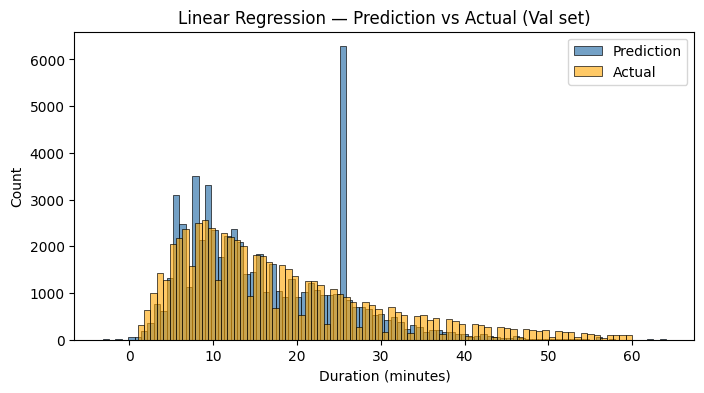

2026/03/25 06:33:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:33:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression → RMSE train: 5.6996 | RMSE val: 7.7587
Run ID: 14c82c1b59b94561a7498cec518b85fd


In [ ]:
with mlflow.start_run(run_name="LinearRegression-baseline"):

    # Log parameters
    mlflow.log_param("model_type",   "LinearRegression")
    mlflow.log_param("features",     str(categorical + numerical))
    mlflow.log_param("train_data",   "green_tripdata_2021-01.parquet")
    mlflow.log_param("val_data",     "green_tripdata_2021-02.parquet")
    mlflow.log_param("train_size",   len(df_train))
    mlflow.log_param("val_size",     len(df_val))
    mlflow.log_param("train_data_path", os.path.abspath(train_path))
    mlflow.log_param("val_data_path",   os.path.abspath(val_path))

    # Train
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    # Evaluate
    y_pred_train = lr.predict(X_train)
    y_pred_val   = lr.predict(X_val)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_val   = root_mean_squared_error(y_val,   y_pred_val)

    # Log metrics
    mlflow.log_metric("rmse_train", rmse_train)
    mlflow.log_metric("rmse_val",   rmse_val)

    # Plot predictions vs actual
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(y_pred_val,  label='Prediction', kde=False, color='steelblue', ax=ax)
    sns.histplot(y_val,       label='Actual',     kde=False, color='orange',    ax=ax, alpha=0.6)
    ax.set_title('Linear Regression — Prediction vs Actual (Val set)')
    ax.set_xlabel('Duration (minutes)')
    ax.legend()
    plt.savefig('lr_pred_vs_actual.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Log artifacts
    mlflow.log_artifact('lr_pred_vs_actual.png')

    # Log the model
    signature = infer_signature(X_train, lr.predict(X_train))
    mlflow.sklearn.log_model(lr, artifact_path="model", signature=signature)

    # Save locally as well (pickle)
    with open('models/lin_reg.bin', 'wb') as f_out:
        pickle.dump((dv, lr), f_out)
    mlflow.log_artifact('models/lin_reg.bin')

    print(f"Linear Regression → RMSE train: {rmse_train:.4f} | RMSE val: {rmse_val:.4f}")
    print(f"Run ID: {mlflow.active_run().info.run_id}")

## Cell 8: Lasso Regression (alpha sweep)

In [ ]:
lasso_alphas = [0.001, 0.01, 0.1, 1.0]

for alpha in lasso_alphas:
    with mlflow.start_run(run_name=f"Lasso-alpha={alpha}"):

        # Log parameters
        mlflow.log_param("model_type", "Lasso")
        mlflow.log_param("alpha",      alpha)
        mlflow.log_param("features",   str(categorical + numerical))
        mlflow.log_param("train_data", "green_tripdata_2021-01.parquet")
        mlflow.log_param("val_data",   "green_tripdata_2021-02.parquet")
        mlflow.log_param("train_size", len(df_train))
        mlflow.log_param("val_size",   len(df_val))
        mlflow.log_param("train_data_path", os.path.abspath(train_path))
        mlflow.log_param("val_data_path",   os.path.abspath(val_path))

        # Train
        lasso = Lasso(alpha=alpha, max_iter=5000)
        lasso.fit(X_train, y_train)

        # Evaluate
        rmse_train = root_mean_squared_error(y_train, lasso.predict(X_train))
        rmse_val   = root_mean_squared_error(y_val,   lasso.predict(X_val))

        # Log metrics
        mlflow.log_metric("rmse_train", rmse_train)
        mlflow.log_metric("rmse_val",   rmse_val)

        # Log model
        signature = infer_signature(X_train, lasso.predict(X_train))
        mlflow.sklearn.log_model(lasso, artifact_path="model", signature=signature)

        print(f"Lasso alpha={alpha:<6} → RMSE train: {rmse_train:.4f} | RMSE val: {rmse_val:.4f}")

2026/03/25 06:34:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:34:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso alpha=0.001  → RMSE train: 8.3455 | RMSE val: 9.2334


2026/03/25 06:34:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:34:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso alpha=0.01   → RMSE train: 10.5505 | RMSE val: 11.1673


2026/03/25 06:34:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:34:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso alpha=0.1    → RMSE train: 11.4969 | RMSE val: 12.1432


2026/03/25 06:34:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:34:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso alpha=1.0    → RMSE train: 11.5621 | RMSE val: 12.2126


## Cell 9: Ridge Regression (alpha sweep)

In [ ]:
ridge_alphas = [0.01, 0.1, 1.0, 10.0]

for alpha in ridge_alphas:
    with mlflow.start_run(run_name=f"Ridge-alpha={alpha}"):

        mlflow.log_param("model_type", "Ridge")
        mlflow.log_param("alpha",      alpha)
        mlflow.log_param("features",   str(categorical + numerical))
        mlflow.log_param("train_data", "green_tripdata_2021-01.parquet")
        mlflow.log_param("val_data",   "green_tripdata_2021-02.parquet")
        mlflow.log_param("train_size", len(df_train))
        mlflow.log_param("val_size",   len(df_val))
        mlflow.log_param("train_data_path", os.path.abspath(train_path))
        mlflow.log_param("val_data_path",   os.path.abspath(val_path))

        ridge = Ridge(alpha=alpha)
        ridge.fit(X_train, y_train)

        rmse_train = root_mean_squared_error(y_train, ridge.predict(X_train))
        rmse_val   = root_mean_squared_error(y_val,   ridge.predict(X_val))

        mlflow.log_metric("rmse_train", rmse_train)
        mlflow.log_metric("rmse_val",   rmse_val)

        signature = infer_signature(X_train, ridge.predict(X_train))
        mlflow.sklearn.log_model(ridge, artifact_path="model", signature=signature)

        print(f"Ridge alpha={alpha:<6} → RMSE train: {rmse_train:.4f} | RMSE val: {rmse_val:.4f}")

2026/03/25 06:34:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:34:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge alpha=0.01   → RMSE train: 5.0023 | RMSE val: 7.5207


2026/03/25 06:34:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:34:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/25 06:34:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Ridge alpha=0.1    → RMSE train: 5.0651 | RMSE val: 7.5255


2026/03/25 06:34:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/25 06:34:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Ridge alpha=1.0    → RMSE train: 5.6458 | RMSE val: 7.7037


2026/03/25 06:34:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge alpha=10.0   → RMSE train: 7.6660 | RMSE val: 8.8468


## Cell 10: XGBoost Hyperparameter Sweep

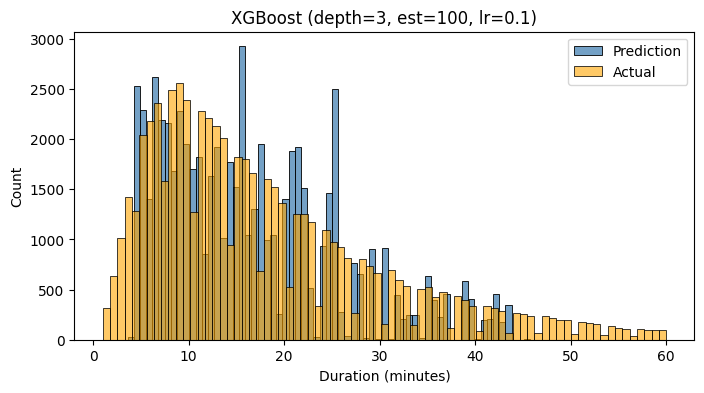

2026/03/25 06:35:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:35:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost → RMSE train: 5.9892 | RMSE val: 6.8043


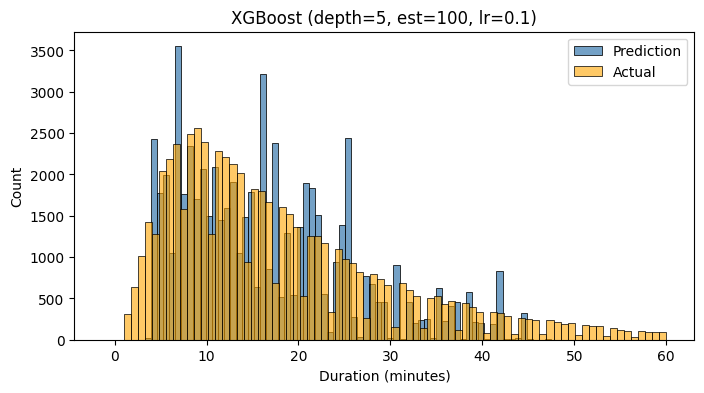

2026/03/25 06:35:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:35:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost → RMSE train: 5.8691 | RMSE val: 6.7367


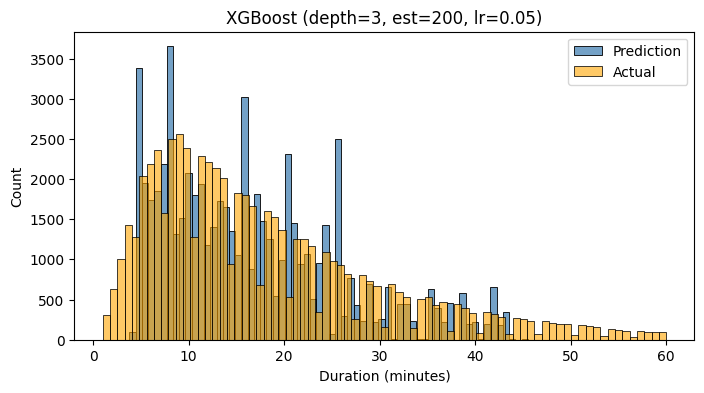

2026/03/25 06:35:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:35:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost → RMSE train: 5.9957 | RMSE val: 6.8102


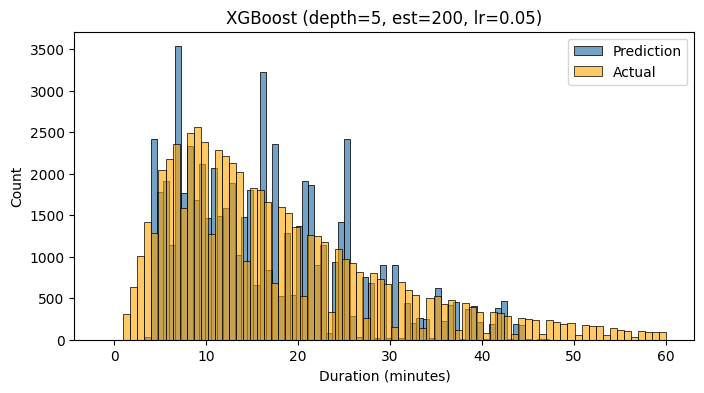

2026/03/25 06:35:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:35:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost → RMSE train: 5.8716 | RMSE val: 6.7393


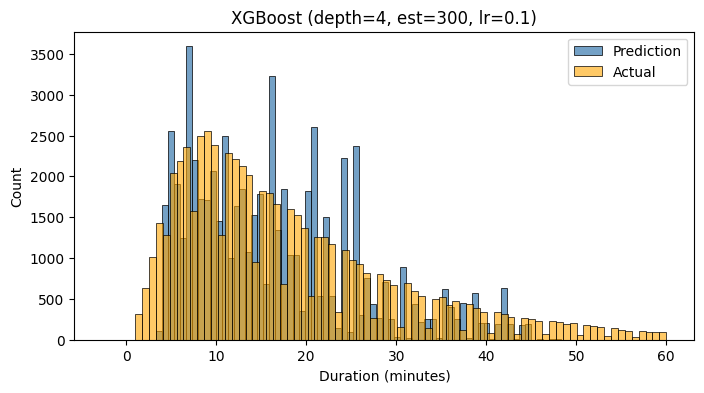

2026/03/25 06:35:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:35:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost → RMSE train: 5.8112 | RMSE val: 6.7104


In [ ]:
# Define hyperparameters to try
xgb_params = [
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1},
    {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1},
    {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05},
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05},
    {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1},
]

for params in xgb_params:
    with mlflow.start_run(run_name=f"XGBoost-depth={params['max_depth']}-est={params['n_estimators']}-lr={params['learning_rate']}"):

        # Log parameters
        mlflow.log_param("model_type", "XGBoost")
        mlflow.log_param("n_estimators", params['n_estimators'])
        mlflow.log_param("max_depth", params['max_depth'])
        mlflow.log_param("learning_rate", params['learning_rate'])
        mlflow.log_param("features", str(categorical + numerical))
        mlflow.log_param("train_data", "green_tripdata_2021-01.parquet")
        mlflow.log_param("val_data", "green_tripdata_2021-02.parquet")
        mlflow.log_param("train_size", len(df_train))
        mlflow.log_param("val_size", len(df_val))
        mlflow.log_param("train_data_path", os.path.abspath(train_path))
        mlflow.log_param("val_data_path",   os.path.abspath(val_path))

        # Train XGBoost
        xgb_model = XGBRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            random_state=42,
            verbosity=0
        )
        xgb_model.fit(X_train, y_train)

        # Evaluate
        y_pred_train = xgb_model.predict(X_train)
        y_pred_val   = xgb_model.predict(X_val)

        rmse_train = root_mean_squared_error(y_train, y_pred_train)
        rmse_val   = root_mean_squared_error(y_val, y_pred_val)

        # Log metrics
        mlflow.log_metric("rmse_train", rmse_train)
        mlflow.log_metric("rmse_val", rmse_val)

        # Plot predictions vs actual
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.histplot(y_pred_val,  label='Prediction', kde=False, color='steelblue', ax=ax)
        sns.histplot(y_val,       label='Actual',     kde=False, color='orange',    ax=ax, alpha=0.6)
        ax.set_title(f'XGBoost (depth={params["max_depth"]}, est={params["n_estimators"]}, lr={params["learning_rate"]})')
        ax.set_xlabel('Duration (minutes)')
        ax.legend()
        plot_path = f'xgb_pred_vs_actual_{params["max_depth"]}_{params["n_estimators"]}.png'
        plt.savefig(plot_path, dpi=100, bbox_inches='tight')
        plt.show()

        # Log artifact
        mlflow.log_artifact(plot_path)

        # Log model
        signature = infer_signature(X_train, xgb_model.predict(X_train))
        mlflow.sklearn.log_model(xgb_model, artifact_path="model", signature=signature)

        print(f"XGBoost → RMSE train: {rmse_train:.4f} | RMSE val: {rmse_val:.4f}")

## Cell 10b: XGBoost + Hyperopt (Bayesian Optimization)

Starting Hyperopt search (50 trials)...


2026/03/25 06:36:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:36:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/25 06:36:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 06:36:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p


Hyperopt finished.
Best val RMSE : 6.4013 minutes
Best params   : {'colsample_bytree': np.float64(0.8023620511175745), 'learning_rate': np.float64(0.611085298296599), 'max_depth': np.float64(6.0), 'min_child_weight': np.float64(4.0), 'n_estimators': np.float64(410.0), 'reg_alpha': np.float64(0.7159399671441259), 'reg_lambda': np.float64(0.3210523676767982), 'subsample': np.float64(0.9217203963057945)}


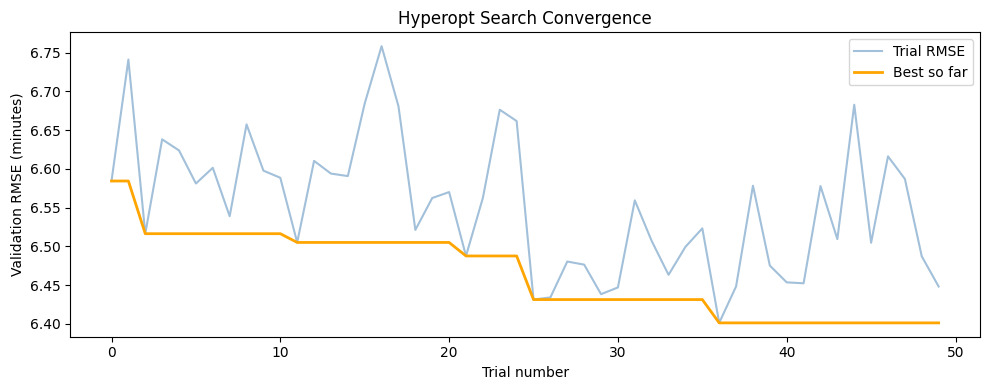

In [ ]:
# Install hyperopt if not already available
!pip install hyperopt --quiet

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

# Define the search space
search_space = {
    'n_estimators':  scope.int(hp.quniform('n_estimators',  50,  500, 10)),
    'max_depth':     scope.int(hp.quniform('max_depth',      2,   8,  1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),   # exp(-3)~0.05 to exp(0)=1
    'subsample':     hp.uniform('subsample',     0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'min_child_weight': scope.int(hp.quniform('min_child_weight', 1, 10, 1)),
    'reg_alpha':     hp.loguniform('reg_alpha',  -5, 2),
    'reg_lambda':    hp.loguniform('reg_lambda', -5, 2),
}

# Objective function — called by Hyperopt on each trial
def objective(params):
    with mlflow.start_run(run_name="Hyperopt-XGBoost", nested=True):

        # Log all hyperparameters
        mlflow.log_param('model_type',       'XGBoost-Hyperopt')
        mlflow.log_param('n_estimators',     params['n_estimators'])
        mlflow.log_param('max_depth',        params['max_depth'])
        mlflow.log_param('learning_rate',    round(params['learning_rate'], 6))
        mlflow.log_param('subsample',        round(params['subsample'], 4))
        mlflow.log_param('colsample_bytree', round(params['colsample_bytree'], 4))
        mlflow.log_param('min_child_weight', params['min_child_weight'])
        mlflow.log_param('reg_alpha',        round(params['reg_alpha'], 6))
        mlflow.log_param('reg_lambda',       round(params['reg_lambda'], 6))
        mlflow.log_param('features',         str(categorical + numerical))
        mlflow.log_param('train_data',       'green_tripdata_2021-01.parquet')
        mlflow.log_param('val_data',         'green_tripdata_2021-02.parquet')
        mlflow.log_param('train_data_path',  os.path.abspath(train_path))
        mlflow.log_param('val_data_path',    os.path.abspath(val_path))

        # Train
        model = XGBRegressor(
            n_estimators=     params['n_estimators'],
            max_depth=        params['max_depth'],
            learning_rate=    params['learning_rate'],
            subsample=        params['subsample'],
            colsample_bytree= params['colsample_bytree'],
            min_child_weight= params['min_child_weight'],
            reg_alpha=        params['reg_alpha'],
            reg_lambda=       params['reg_lambda'],
            random_state=42,
            verbosity=0,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)

        # Evaluate
        rmse_train = root_mean_squared_error(y_train, model.predict(X_train))
        rmse_val   = root_mean_squared_error(y_val,   model.predict(X_val))

        mlflow.log_metric('rmse_train', rmse_train)
        mlflow.log_metric('rmse_val',   rmse_val)

        # Log model
        signature = infer_signature(X_train, model.predict(X_train))
        mlflow.sklearn.log_model(model, artifact_path='model', signature=signature)

    # Hyperopt minimizes the returned loss
    return {'loss': rmse_val, 'status': STATUS_OK}


# Run Hyperopt search (50 trials, TPE algorithm)
MAX_EVALS = 50
trials = Trials()

print(f'Starting Hyperopt search ({MAX_EVALS} trials)...')
with mlflow.start_run(run_name='Hyperopt-XGBoost-search'):
    mlflow.log_param('optimizer',  'TPE')
    mlflow.log_param('max_evals',  MAX_EVALS)
    mlflow.log_param('model_type', 'XGBoost-Hyperopt')

    best_params = fmin(
        fn=objective,
        space=search_space,
        algo=tpe.suggest,
        max_evals=MAX_EVALS,
        trials=trials,
        rstate=np.random.default_rng(42),
        verbose=False,
    )

    best_val_rmse = min(t['result']['loss'] for t in trials.trials)
    mlflow.log_metric('best_rmse_val', best_val_rmse)

print(f'\nHyperopt finished.')
print(f'Best val RMSE : {best_val_rmse:.4f} minutes')
print(f'Best params   : {best_params}')

# Plot convergence curve
trial_losses = [t['result']['loss'] for t in trials.trials]
best_so_far  = [min(trial_losses[:i+1]) for i in range(len(trial_losses))]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trial_losses, color='steelblue', alpha=0.5, label='Trial RMSE')
ax.plot(best_so_far,  color='orange',    linewidth=2, label='Best so far')
ax.set_xlabel('Trial number')
ax.set_ylabel('Validation RMSE (minutes)')
ax.set_title('Hyperopt Search Convergence')
ax.legend()
plt.tight_layout()
plt.savefig('hyperopt_convergence.png', dpi=100, bbox_inches='tight')
plt.show()

## Cell 11: Compare All Runs Programmatically

            tags.mlflow.runName params.model_type params.alpha params.n_estimators params.max_depth params.learning_rate  metrics.rmse_train  metrics.rmse_val                           run_id
               Hyperopt-XGBoost  XGBoost-Hyperopt         None                 410                6             0.611085            5.261951          6.401277 ce9ca2f0fc934d37b011d4f105cb1f45
               Hyperopt-XGBoost  XGBoost-Hyperopt         None                 290                7             0.562704            5.353435          6.431390 c7841452051c4d59aac1ab6ced754d60
               Hyperopt-XGBoost  XGBoost-Hyperopt         None                 290                7             0.869124            5.321089          6.434176 ba2da80010e946ed9c13b7d91de7b47b
               Hyperopt-XGBoost  XGBoost-Hyperopt         None                 260                8             0.417427            5.348208          6.438365 853cd7078bb64261bc9bdca959dea471
               Hyperopt-XGBoost  XGBoost

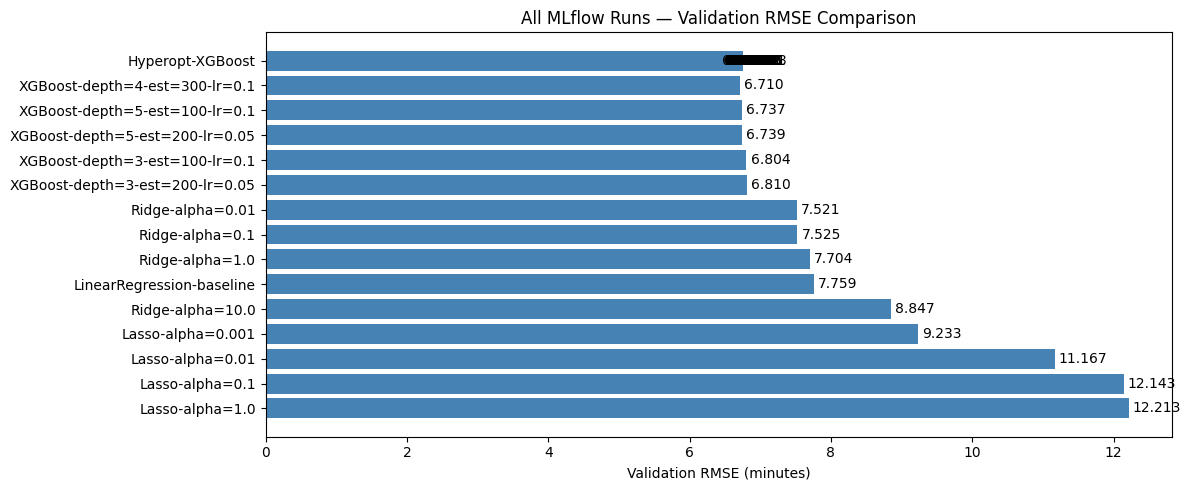

In [ ]:
# Pull all runs from MLflow into a dataframe
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.rmse_val ASC"]
)

# Show key columns
cols = ['tags.mlflow.runName', 'params.model_type', 'params.alpha',
        'params.n_estimators', 'params.max_depth', 'params.learning_rate',
        'metrics.rmse_train', 'metrics.rmse_val', 'run_id']
print(runs_df[cols].to_string(index=False))

# Visual comparison of all runs
plot_df = runs_df[['tags.mlflow.runName', 'metrics.rmse_val']].dropna()
plot_df = plot_df.sort_values('metrics.rmse_val')
plot_df.columns = ['Run', 'RMSE Val']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(plot_df['Run'], plot_df['RMSE Val'], color='steelblue')
ax.set_xlabel('Validation RMSE (minutes)')
ax.set_title('All MLflow Runs — Validation RMSE Comparison')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('all_runs_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## Cell 12: Load the Best Model

In [ ]:
best_run = runs_df.sort_values('metrics.rmse_val').iloc[0]
best_run_id   = best_run['run_id']
best_run_name = best_run['tags.mlflow.runName']
best_rmse     = best_run['metrics.rmse_val']

print(f"Best run  : {best_run_name}")
print(f"Run ID    : {best_run_id}")
print(f"RMSE Val  : {best_rmse:.4f} minutes")

# Load best model directly from MLflow
best_model = mlflow.sklearn.load_model(f"runs:/{best_run_id}/model")
print(f"\nLoaded model: {best_model}")

# Use the best model to predict on validation set
y_pred_best = best_model.predict(X_val)
print(f"Sample predictions (minutes): {y_pred_best[:10].round(2)}")
print(f"Actual values       (minutes): {y_val[:10].round(2)}")

Best run  : Hyperopt-XGBoost
Run ID    : ce9ca2f0fc934d37b011d4f105cb1f45
RMSE Val  : 6.4013 minutes



Loaded model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8023620511175745, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.611085298296599,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=4, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=410, n_jobs=-1,
             num_parallel_tree=None, ...)
Sample predictions (minutes): [15.72  7.28 14.55 24.5   9.75 17.11 11.66  8.65  8.99 18.56]
Actual values       (minutes): [17.92  6.5  15.25 18.23  8.97  7.85  9.7  11.28  8.73  1.72]


## Cell 13: Start MLflow UI (with ngrok)

In [ ]:
# Remote MLflow UI is already available — no local server needed
# ✅ Open the MLflow UI at:
MLFLOW_UI_URL = "http://ec2-16-16-201-85.eu-north-1.compute.amazonaws.com:5000"
print(f"MLflow UI: {MLFLOW_UI_URL}")
print("Open the link above in your browser to view all runs and compare models.")


ModuleNotFoundError: No module named 'pyngrok'

## Cell 14: Final Summary

In [ ]:
print("=" * 60)
print("  EXPERIMENT SUMMARY")
print("=" * 60)
print(f"  Experiment   : {EXPERIMENT_NAME}")
print(f"  Total runs   : {len(runs_df)}")
print(f"  Best model   : {best_run_name}")
print(f"  Best RMSE    : {best_rmse:.4f} minutes")
print("=" * 60)
print(f"  Tracking URI : http://ec2-16-16-201-85.eu-north-1.compute.amazonaws.com:5000")
print(f"  MLflow UI    : http://ec2-16-16-201-85.eu-north-1.compute.amazonaws.com:5000")
print("  Artifacts    : s3://mlflow-artifacts-remote-maha/")
print("  Backend DB   : RDS PostgreSQL (mlflow-backend-db)")
print("=" * 60)


In [ ]:
# No local mlflow.db to download — all data is stored on the remote server
# Params, metrics → RDS PostgreSQL
# Artifacts (models, plots) → S3 (mlflow-artifacts-remote-maha)
print("All experiment data is persisted on the remote server.")
print("View runs at: http://ec2-16-16-201-85.eu-north-1.compute.amazonaws.com:5000")


In [ ]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Get the experiment
experiment = client.get_experiment_by_name("nyc-taxi-duration-prediction")
runs = client.search_runs(experiment_ids=[experiment.experiment_id])

print(f"{'Run Name':<45} {'Run ID':<32} {'Model Logged?'}")
print("-" * 90)

for run in runs:
    run_name = run.data.tags.get("mlflow.runName", "unnamed")
    run_id   = run.info.run_id

    # List artifacts under 'model/' path
    artifacts = client.list_artifacts(run_id, path="model")

    has_model = "✅ Yes" if artifacts else "❌ No"
    print(f"{run_name:<45} {run_id:<32} {has_model}")

In [ ]:
import mlflow

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.rmse_val ASC"]
)

# Filter only runs that have a logged model artifact
runs_with_model = runs_df[runs_df['artifact_uri'].notna()].copy()

# Top 3
top3 = runs_with_model.head(3)

for rank, (_, run) in enumerate(top3.iterrows(), start=1):
    print(f"\n{'='*55}")
    print(f"  🏆 Rank #{rank}")
    print(f"{'='*55}")
    print(f"  Run Name   : {run.get('tags.mlflow.runName', 'N/A')}")
    print(f"  Run ID     : {run['run_id']}")
    print(f"  Model Type : {run.get('params.model_type', 'N/A')}")
    print(f"  RMSE Val   : {run.get('metrics.rmse_val', 'N/A'):.4f}")
    print(f"  RMSE Train : {run.get('metrics.rmse_train', 'N/A'):.4f}")
    print(f"  Alpha      : {run.get('params.alpha', 'N/A')}")
    print(f"  N estimators: {run.get('params.n_estimators', 'N/A')}")
    print(f"  Max Depth  : {run.get('params.max_depth', 'N/A')}")
    print(f"  Learning Rate: {run.get('params.learning_rate', 'N/A')}")
    print(f"  Artifact URI: {run['artifact_uri']}")
    print(f"  Model URI  : runs:/{run['run_id']}/model")